In [1]:
#
# Copyright (c) 2011 Christopher Felton
#
# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.
#
# This program is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
# GNU Lesser General Public License for more details.
#
# You should have received a copy of the GNU Lesser General Public License
# along with this program.  If not, see <http://www.gnu.org/licenses/>.
#

# The following is derived from the slides presented by
# Alexander Kain for CS506/606 "Special Topics: Speech Signal Processing"
# CSLU / OHSU, Spring Term 2011.

import numpy as np
import matplotlib.pyplot as plt
from  matplotlib import patches
from matplotlib.figure import Figure
from matplotlib import rcParams
    
def zplane(b,a,filename=None):
    """Plot the complex z-plane given a transfer function.
    """

    # get a figure/plot
    ax = plt.subplot(111)

    # create the unit circle
    uc = patches.Circle((0,0), radius=1, fill=False,
                        color='black', ls='dashed')
    ax.add_patch(uc)

    # The coefficients are less than 1, normalize the coeficients
    if np.max(b) > 1:
        kn = np.max(b)
        b = b/float(kn)
    else:
        kn = 1

    if np.max(a) > 1:
        kd = np.max(a)
        a = a/float(kd)
    else:
        kd = 1
        
    # Get the poles and zeros
    p = np.roots(a)
    z = np.roots(b)
    k = kn/float(kd)
    
    # Plot the zeros and set marker properties    
    t1 = plt.plot(z.real, z.imag, 'go', ms=10)
    plt.setp( t1, markersize=10.0, markeredgewidth=1.0,
              markeredgecolor='k', markerfacecolor='g')

    # Plot the poles and set marker properties
    t2 = plt.plot(p.real, p.imag, 'rx', ms=10)
    plt.setp( t2, markersize=12.0, markeredgewidth=3.0,
              markeredgecolor='r', markerfacecolor='r')

    ax.spines['left'].set_position('center')
    ax.spines['bottom'].set_position('center')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # set the ticks
    r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
    ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)

    if filename is None:
        plt.show()
    else:
        plt.savefig(filename)
    

    return z, p, k


In [2]:
import numpy as np

def impseq(n0,n1,n2):
    
    #      Generates x(n) = delta(n-n0); n1 <= n <= n2
    #      ----------------------------------------------
    #      [x,n] = impseq(n0,n1,n2)
    #     
        
    n=np.array(range(n1,n2+1))
    x = n-n0
    for i in range(len(x)):
        if x[i]!=0: x[i]=0
        else: x[i]=1
    #x = (n-n0) == 0
    return [x,n]

def stepseq(n0,n1,n2):
    #     Generates x(n) = u(n-n0); n1 <= n <= n2
    #     ------------------------------------------
    #     [x,n] = stepseq(n0,n1,n2)
    #
    n=np.arange(n1,n2+1)
    x = n-n0
    for i in range(len(x)):
        if x[i]<0: x[i]=0
        else: x[i]=1
    #x = [(n-n0) >= 0]
    return [x,n]

def  sigadd(x1,n1,x2,n2):
    # % implements y(n) = x1(n)+x2(n)
    # % -----------------------------
    # % [y,n] = sigadd(x1,n1,x2,n2)
    # % y = sum sequence over n, which includes n1 and n2
    # % x1 = first sequence over n1
    # % x2 = second sequence over n2 (n2 can be different from n1)
    # %
    n = np.arange(min(n1.min(0),n2.min(0)),max(n1.max(0),n2.max(0))+1) # duration of y(n)
    y1 = np.zeros((1,len(n)))  #initialization
    y1=y1[0,:]
    y2 = y1.copy()
    y1[np.nonzero(np.logical_and((n>=n1.min(0)),(n<=n1.max(0)))==1)]=x1.copy()
    y2[np.nonzero(np.logical_and((n>=n2.min(0)),(n<=n2.max(0)))==1)]=x2.copy()
    y = y1+y2;
    return [y,n]


def  sigmult(x1,n1,x2,n2):
    # % implements y(n) = x1(n)*x2(n)
    # % -----------------------------
    # % [y,n] = sigmult(x1,n1,x2,n2)
    # % y = product sequence over n, which includes n1 and n2
    # % x1 = first sequence over n1
    # %
    n = np.arange(min(n1.min(0),n2.min(0)),max(n1.max(0),n2.max(0))+1) # duration of y(n)
    y1 = np.zeros((1,len(n)))  #initialization
    y1=y1[0,:]
    y2 = y1.copy()
    y1[np.nonzero(np.logical_and((n>=n1.min(0)),(n<=n1.max(0)))==1)]=x1.copy()
    y2[np.nonzero(np.logical_and((n>=n2.min(0)),(n<=n2.max(0)))==1)]=x2.copy()
    y = y1*y2
    return [y,n]


def sigshift(x,m,k):
    # % implements y(n) = x(n-k)
    # % -------------------------
    # % [y,n] = sigshift(x,m,k)
    # %
    n = m+k
    y = x.copy()
    return [y,n]


def sigfold(x,n):
    # % implements y(n) = x(-n)
    # % -----------------------
    # % [y,n] = sigfold(x,n)
    # %
    y = np.flip(x)
    n = -np.flip(n)
    return [y,n]

def conv_m(x,nx,h,nh):
    # Modified convolution routine for signal processing
    # --------------------------------------------------
    # [y,ny] = conv_m(x,nx,h,nh)
    # [y,ny] = convolution result
    # [x,nx] = first signal
    # [h,nh] = second signal
    # 
    nyb = nx[0]+nh[0]
    nye = nx[len(x)-1] + nh[len(h)-1]
    ny = np.arange(nyb,nye+1)
    y = np.convolve(x,h)
    return [y,ny]

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import lfilter
from scipy.interpolate import CubicSpline
from scipy import signal
from plot_zplane import zplane

from fDSP import (
    impseq,
    stepseq,
    sigadd,
    sigmult,
    sigshift,
    sigfold,
    conv_m
)

# =========================================================
# PLOT UTILITIES
# =========================================================


def plot_signal(n, x, title="Signal", xlabel="n", ylabel="Amplitude"):
    """
    Plota um sinal discreto usando stem.
    """

    plt.figure()
    plt.stem(n, x)
    plt.grid(True)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

def plot_multiple_signals(signals):
    """
    Plota vários sinais discretos.

    signals:
        [
            (n, x, "titulo"),
            ...
        ]
    """

    for n, x, title in signals:

        plt.figure()

        plt.stem(n, x)

        plt.grid(True)

        plt.title(title)

        plt.xlabel("n")

        plt.ylabel("Amplitude")


# =========================================================
# BASIC SIGNAL GENERATORS
# =========================================================


def impulse(n0, n1, n2):
    """
    Gera:
        x(n) = delta(n - n0)
    """

    return impseq(n0, n1, n2)


def step(n0, n1, n2):
    """
    Gera:
        x(n) = u(n - n0)
    """

    return stepseq(n0, n1, n2)


def cosine(A, w, n, phi=0.0):
    """
    Gera:
        x(n) = A*cos(w*n + phi)
    """

    x = A * np.cos(w * n + phi)

    return x


def sine(A, w, n, phi=0.0):
    """
    Gera:
        x(n) = A*sin(w*n + phi)
    """

    x = A * np.sin(w * n + phi)

    return x


def exponential(a, n):
    """
    Gera:
        x(n) = exp(a*n)
    """

    x = np.exp(a * n)

    return x

def gaussian_noise(mean, variance, n):
    """
    Gera ruído gaussiano.

    mean:
        média

    variance:
        variância
    """

    std = np.sqrt(variance)

    x = np.random.normal(mean, std, len(n))

    return x

def uniform_noise(low, high, n):
    """
    Gera sequência uniforme.
    """

    x = np.random.uniform(low, high, len(n))

    return x

# =========================================================
# SIGNAL OPERATIONS
# =========================================================


def add(x1, n1, x2, n2):
    """
    Soma dois sinais.
    """

    return sigadd(x1, n1, x2, n2)


def multiply(x1, n1, x2, n2):
    """
    Multiplica dois sinais.
    """

    return sigmult(x1, n1, x2, n2)


def shift(x, n, k):
    """
    Implementa:
        y(n) = x(n-k)

    k > 0 -> direita
    k < 0 -> esquerda
    """

    return sigshift(x, n, k)


def fold(x, n):
    """
    Implementa:
        y(n) = x(-n)
    """

    return sigfold(x, n)


def convolution(x, nx, h, nh):
    """
    Convolução discreta.
    """

    return conv_m(x, nx, h, nh)

def apply_system(system, x, n):
    """
    Aplica um sistema a um sinal.

    system:
        função do tipo:
            y = system(x, n)
    """

    y = system(x, n)

    return y

def signals_equal(x1, x2, tolerance=1e-10):
    """
    Verifica se dois sinais são aproximadamente iguais.
    """

    return np.allclose(x1, x2, atol=tolerance)

# =========================================================
# SYSTEM TEST UTILITIES
# =========================================================

def test_linearity(system, x1, x2, a1, a2, n):
    """
    Testa linearidade:

        T[a1*x1 + a2*x2]
        =
        a1*T[x1] + a2*T[x2]
    """

    x = a1*x1 + a2*x2

    left = system(x, n)

    right = (
        a1*system(x1, n)
        + a2*system(x2, n)
    )

    return signals_equal(left, right)

def test_time_invariance(system, x, n, k):
    """
    Testa invariância no tempo.

    Verifica:

        T[x(n-k)] == y(n-k)
    """

    # entrada deslocada
    xs, ns = shift(x, n, k)

    y1 = system(xs, ns)

    # saída original
    y = system(x, n)

    # desloca saída
    y2, ny2 = shift(y, n, k)

    return signals_equal(y1, y2)

# =========================================================
# DIGITAL FILTERS / LTI SYSTEMS
# =========================================================


def apply_filter(b, a, x):
    """
    Aplica filtro digital definido por:

        a[0]y(n) + a[1]y(n-1)+... =
        b[0]x(n) + b[1]x(n-1)+...

    Usa scipy.signal.lfilter.

    Parâmetros:
        b -> coeficientes da entrada
        a -> coeficientes da saída
        x -> sinal de entrada
    """

    y = lfilter(b, a, x)

    return y

# =========================================================
# FREQUENCY DOMAIN / DTFT
# =========================================================

def frequency_range(w1=-np.pi, w2=np.pi, points=1000):
    """
    Gera eixo de frequência.
    """

    return np.linspace(w1, w2, points)


def dtft(x, n, w):
    """
    Calcula DTFT numericamente.

    X(e^jw)
    """

    X = np.zeros(len(w), dtype=complex)

    for i, wi in enumerate(w):

        X[i] = np.sum(
            x * np.exp(-1j * wi * n)
        )

    return X


def plot_dtft(w, X, title="DTFT"):
    """
    Plota magnitude e fase da DTFT.
    """

    # -----------------------------------------
    # Magnitude
    # -----------------------------------------

    plt.figure()

    plt.plot(w, np.abs(X))

    plt.grid(True)

    plt.title(f"{title} - Magnitude")

    plt.xlabel("ω")

    plt.ylabel("|X(e^jw)|")

    # -----------------------------------------
    # Fase
    # -----------------------------------------

    plt.figure()

    plt.plot(w, np.angle(X))

    plt.grid(True)

    plt.title(f"{title} - Fase")

    plt.xlabel("ω")

    plt.ylabel("Fase (rad)")

def lti_response_to_sum_of_sinusoids(h, n, components):
    """
    h: resposta ao impulso do sistema
    n: eixo do tempo (só para referência)
    components: lista de senoides
        [(w, A, phase, 'cos'/'sin'), ...]
    """

    # -----------------------------------------
    # frequência
    # -----------------------------------------
    w = frequency_range(-np.pi, np.pi, 4000)

    H = dtft(h, n, w)

    y = np.zeros(len(n))

    # -----------------------------------------
    # para cada senoide
    # -----------------------------------------
    for (w0, A, phase, kind) in components:

        # pega resposta do sistema na frequência
        idx = np.argmin(np.abs(w - w0))
        H0 = H[idx]

        gain = np.abs(H0)
        phi = np.angle(H0)

        if kind == 'cos':

            y += A * gain * np.cos(w0*n + phase + phi)

        elif kind == 'sin':

            y += A * gain * np.sin(w0*n + phase + phi)

    return y

def frequency_response(h, n, w0):
    """
    Calcula H(e^jw0) em uma frequência específica.

    Faz o folding automático da frequência
    para a faixa [-pi, pi].
    """

    # -----------------------------------------
    # folding para faixa principal
    # -----------------------------------------

    w_folded = ((w0 + np.pi) % (2*np.pi)) - np.pi

    # -----------------------------------------
    # DTFT em w0
    # -----------------------------------------

    H = np.sum(
        h * np.exp(-1j * w_folded * n)
    )

    return H

def fold_digital_frequency(w):
    """
    Dobra frequência digital para a faixa:

        -pi <= w <= pi

    Útil para aliasing.
    """

    return ((w + np.pi) % (2*np.pi)) - np.pi

# =========================================================
# PERIODIC SIGNAL UTILITIES
# =========================================================


def repeat_sequence(pattern, repetitions, origin=0):
    """
    Repete uma sequência periódica.

    Exemplo:
        pattern = [1,2,3]
        repetitions = 4
        origin = 1
    """

    x = np.tile(pattern, repetitions)

    n = np.arange(-origin, len(x) - origin)

    return x, n


def is_periodic(w):
    """
    Verifica se uma senoide discreta é periódica.

    Condição:
        w/(2*pi) deve ser racional.
    """

    ratio = w / (2 * np.pi)

    tolerance = 1e-10

    for N in range(1, 1000):

        K = ratio * N

        if abs(K - round(K)) < tolerance:
            return True, N

    return False, None


def fundamental_period(periods):
    """
    Calcula o período fundamental de uma soma
    de sinais periódicos.

    Usa MMC (mínimo múltiplo comum).

    Exemplo:
        periods = [3,4]

        retorno:
            12
    """

    if len(periods) == 0:
        return None

    N = periods[0]

    for p in periods[1:]:
        N = math.lcm(N, p)

    return N

def discrete_time_range(n1, n2):
    """
    Gera eixo discreto:

        n1 <= n <= n2

    Exemplo:
        discrete_time_range(-10,10)
    """

    return np.arange(n1, n2 + 1)

def base_signal(values, origin_index):
    """
    Cria sinal discreto com origem arbitrária.

    Exemplo:

        values = [2,4,-3,1,-5]
        origin_index = 3

    significa:

        ↑1 está na posição 3
    """

    x = np.array(values)

    n = np.arange(-origin_index, len(values)-origin_index)

    return x, n

# =========================================================
# SPECIAL SIGNALS
# =========================================================


def damped_sine(A, alpha, w, n, phi=0.0):
    """
    Gera:
        x(n) = A*exp(alpha*n)*sin(w*n + phi)
    """

    x = A * np.exp(alpha * n) * np.sin(w * n + phi)

    return x


def beating_cosine(A, w1, w2, n):
    """
    Soma de duas senoides próximas.
    """

    x = A * (np.cos(w1 * n) + np.cos(w2 * n))

    return x

def linear_combination(terms):
    """
    Combinação linear de sinais deslocados.

    Cada termo:
        (coef, x, n, shift)
    """

    if len(terms) == 0:
        raise ValueError("terms não pode ser vazio")

    y = None
    ny = None

    for i, (coef, x, n, k) in enumerate(terms):

        xs, ns = shift(x, n, k)

        xs = coef * xs

        if i == 0:
            y = xs
            ny = ns

        else:
            y, ny = add(y, ny, xs, ns)

    return y, ny

# =========================================================
# SAMPLING / RECONSTRUCTION
# =========================================================
def continuous_time_range(t1, t2, dt):
    """
    Gera eixo contínuo.

    Exemplo:
        continuous_time_range(0,1,0.001)
    """

    return np.arange(t1, t2 + dt, dt)

def continuous_cosine(A, f, t, phi=0.0):
    """
    Gera:

        x_a(t) = A*cos(2*pi*f*t + phi)

    f em Hz
    """

    return A * np.cos(2*np.pi*f*t + phi)

def continuous_sine(A, f, t, phi=0.0):
    """
    Gera:

        x_a(t) = A*sin(2*pi*f*t + phi)

    f em Hz
    """

    return A * np.sin(2*np.pi*f*t + phi)

def sample_signal(xa, ta, Ts):
    """
    Amostra um sinal contínuo.

    Retorna:
        xn  -> sinal discreto
        n   -> eixo discreto
        ts  -> instantes de amostragem
    """

    sample_indices = np.arange(
        0,
        len(ta),
        int(round(Ts / (ta[1] - ta[0])))
    )

    xn = xa[sample_indices]

    ts = ta[sample_indices]

    n = np.arange(len(xn))

    return xn, n, ts

def analog_to_digital_frequency(f, fs):
    """
    Converte frequência analógica (Hz)
    para frequência digital (rad/amostra).

    ω = 2πf/fs
    """

    return 2 * np.pi * f / fs

def alias_frequency(f, fs):
    """
    Calcula frequência observada após aliasing.

    Retorna frequência equivalente
    dentro da faixa de Nyquist.
    """

    fa = f % fs

    if fa > fs/2:
        fa = fs - fa

    return fa

def fft_spectrum(x, fs):
    """
    Calcula espectro via FFT.

    Retorna:
        f -> eixo frequência
        X -> magnitude
    """

    N = len(x)

    X = np.fft.fftshift(np.fft.fft(x))

    f = np.fft.fftshift(
        np.fft.fftfreq(N, d=1/fs)
    )

    return f, np.abs(X)

def plot_spectrum(f, X, title="Spectrum"):
    """
    Plota espectro.
    """

    plt.figure()

    plt.plot(f, X)

    plt.grid(True)

    plt.title(title)

    plt.xlabel("Frequency (Hz)")

    plt.ylabel("Magnitude")

def plot_continuous_signal(t, x,
                           title="Signal",
                           xlabel="t",
                           ylabel="Amplitude"):
    """
    Plota sinal contínuo.
    """

    plt.figure()

    plt.plot(t, x)

    plt.grid(True)

    plt.title(title)

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

def sampling_frequency(Ts):
    return 1/Ts

def sinc_reconstruction(xn, ts, t):
    """
    Reconstrução ideal por sinc interpolation.

    xn -> amostras
    ts -> tempos das amostras
    t  -> eixo contínuo reconstruído
    """

    Ts = ts[1] - ts[0]

    y = np.zeros(len(t))

    for n in range(len(xn)):

        y += xn[n] * np.sinc((t - ts[n]) / Ts)

    return y

def spline_reconstruction(xn, ts, t):
    """
    Reconstrução usando cubic spline.
    """

    spline = CubicSpline(ts, xn)

    return spline(t)

# =========================================================
# Z-TRANSFORM UTILITIES
# =========================================================
def plot_pole_zero(b, a):
    """
    Plota polos e zeros de:

        H(z) = B(z)/A(z)

    b -> numerador
    a -> denominador
    """

    plt.figure()

    zplane(np.array(b), np.array(a))

def frequency_response_filter(b, a):
    """
    Calcula resposta em frequência
    de um filtro digital.
    """

    w, H = signal.freqz(b, a)

    return w, H

def plot_frequency_response(w, H, title="Resposta em frequência"):

    # magnitude
    plt.figure()

    plt.plot(w/np.pi, np.abs(H))

    plt.grid(True)

    plt.title(f"{title} - Magnitude")

    plt.xlabel("Frequência (×π rad/amostra)")

    plt.ylabel("|H(e^jw)|")

    # fase
    plt.figure()

    plt.plot(w/np.pi, np.angle(H))

    plt.grid(True)

    plt.title(f"{title} - Fase")

    plt.xlabel("Frequência (×π rad/amostra)")

    plt.ylabel("Fase (rad)")

def partial_fraction(b, a):
    """
    Expansão em frações parciais:

        B(z)/A(z)

    Retorna:
        R -> resíduos
        p -> polos
        C -> termo direto
    """

    R, p, C = signal.residuez(b, a)

    return R, p, C

def impulse_response(b, a, n1=0, n2=20):
    """
    Calcula resposta ao impulso
    de um sistema H(z).
    """

    delta, n = impulse(0, n1, n2)

    h = apply_filter(b, a, delta)

    return h, n

def print_difference_equation(b, a):
    """
    Mostra estrutura da equação
    de diferenças do filtro.
    """

    print("Coeficientes da entrada (b):")
    print(b)

    print("Coeficientes da saída (a):")
    print(a)

def poles_zeros(b, a):
    """
    Retorna polos e zeros.
    """

    zeros = np.roots(b)

    poles = np.roots(a)

    return zeros, poles

Sequências iguais?
False


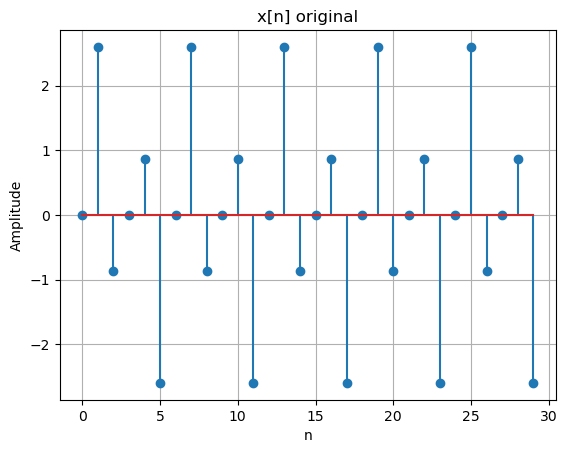

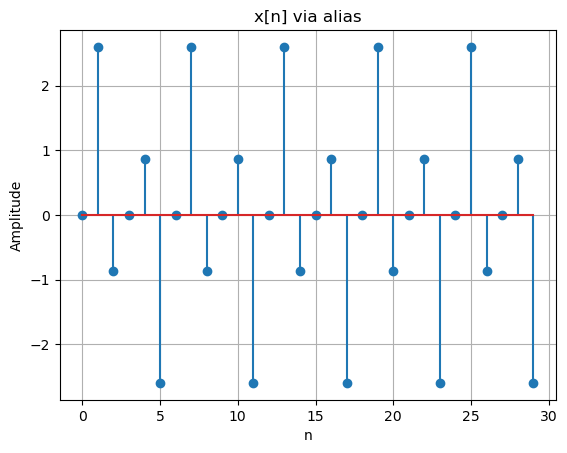

In [4]:
fs = 10000

n = np.arange(0, 30)

# -----------------------------------------
# sequência original
# -----------------------------------------

x1 = (
    np.sin((np.pi/3)*n)
    +
    2*np.sin((2*np.pi/3)*n)
)

# -----------------------------------------
# frequências equivalentes
# -----------------------------------------

f1 = 1666.67
f2 = 3333.33

f1_alias = 11666.67
f2_alias = 13333.33

# -----------------------------------------
# sequência obtida pelos aliases
# -----------------------------------------

w1 = analog_to_digital_frequency(
    f1_alias,
    fs
)

w2 = analog_to_digital_frequency(
    f2_alias,
    fs
)

x2 = (
    np.sin(w1*n)
    +
    2*np.sin(w2*n)
)

# -----------------------------------------
# plots
# -----------------------------------------

plot_multiple_signals([
    (n, x1, "x[n] original"),
    (n, x2, "x[n] via alias")
])

print("Sequências iguais?")

print(
    np.allclose(x1, x2)
)

plt.show()